# ML Astronomy

## Imports

In [2]:
import os
import math
import numpy as np

import kagglehub
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform

/srv/alyra/dev-ia/ml-astronomy/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset loading

In [3]:
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")
filename = "star_classification.csv"
filepath = os.path.join(path, filename)
df = pd.read_csv(filepath)

## EDA

### Dataset analysis

In [51]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

In [54]:
print(f"Lines: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Lines: 100000
Columns: 18


In [55]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


### Target distribution

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


<Axes: xlabel='class', ylabel='count'>

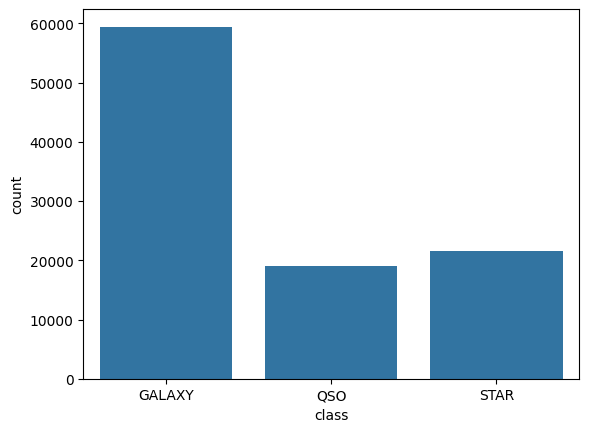

In [3]:
print(df["class"].value_counts())
sns.countplot(data=df, x="class")

### Target distribution after treatment

### Missing values

In [58]:
df.isna().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

### Numeric distribution

array([[<Axes: title={'center': 'obj_ID'}>,
        <Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'delta'}>, <Axes: title={'center': 'u'}>],
       [<Axes: title={'center': 'g'}>, <Axes: title={'center': 'r'}>,
        <Axes: title={'center': 'i'}>, <Axes: title={'center': 'z'}>],
       [<Axes: title={'center': 'run_ID'}>,
        <Axes: title={'center': 'rerun_ID'}>,
        <Axes: title={'center': 'cam_col'}>,
        <Axes: title={'center': 'field_ID'}>],
       [<Axes: title={'center': 'spec_obj_ID'}>,
        <Axes: title={'center': 'redshift'}>,
        <Axes: title={'center': 'plate'}>,
        <Axes: title={'center': 'MJD'}>],
       [<Axes: title={'center': 'fiber_ID'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

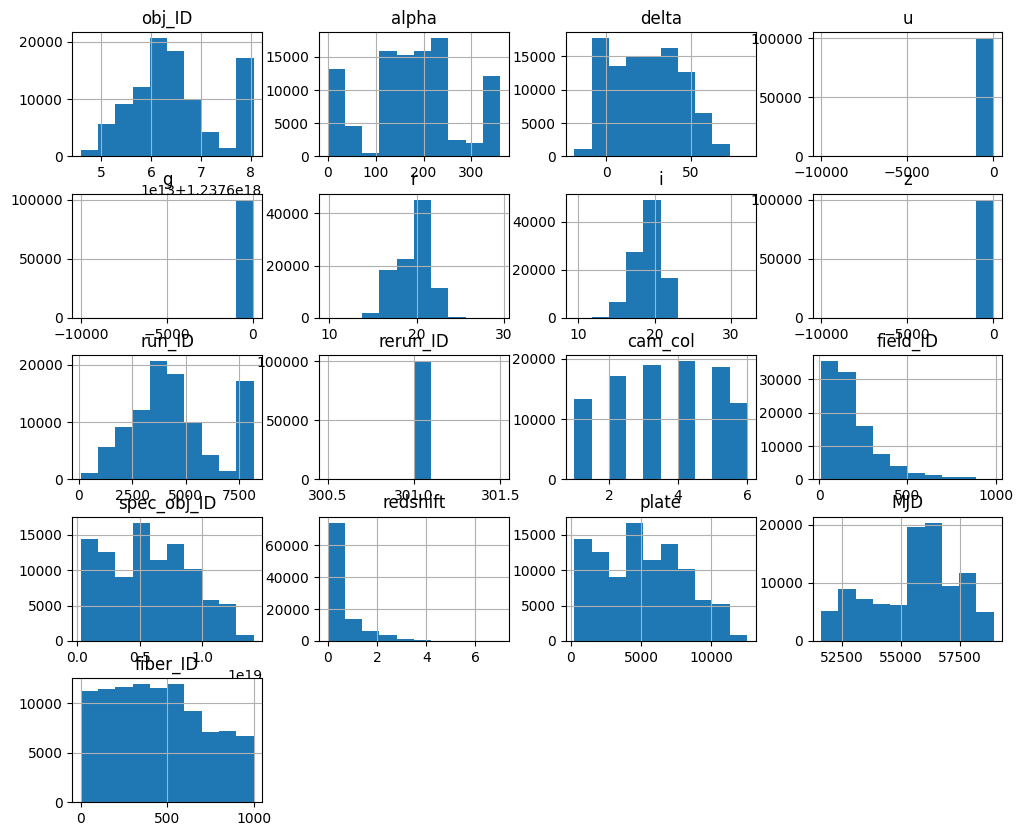

In [59]:
df.hist(figsize=(12, 10))

### Comparison with the target

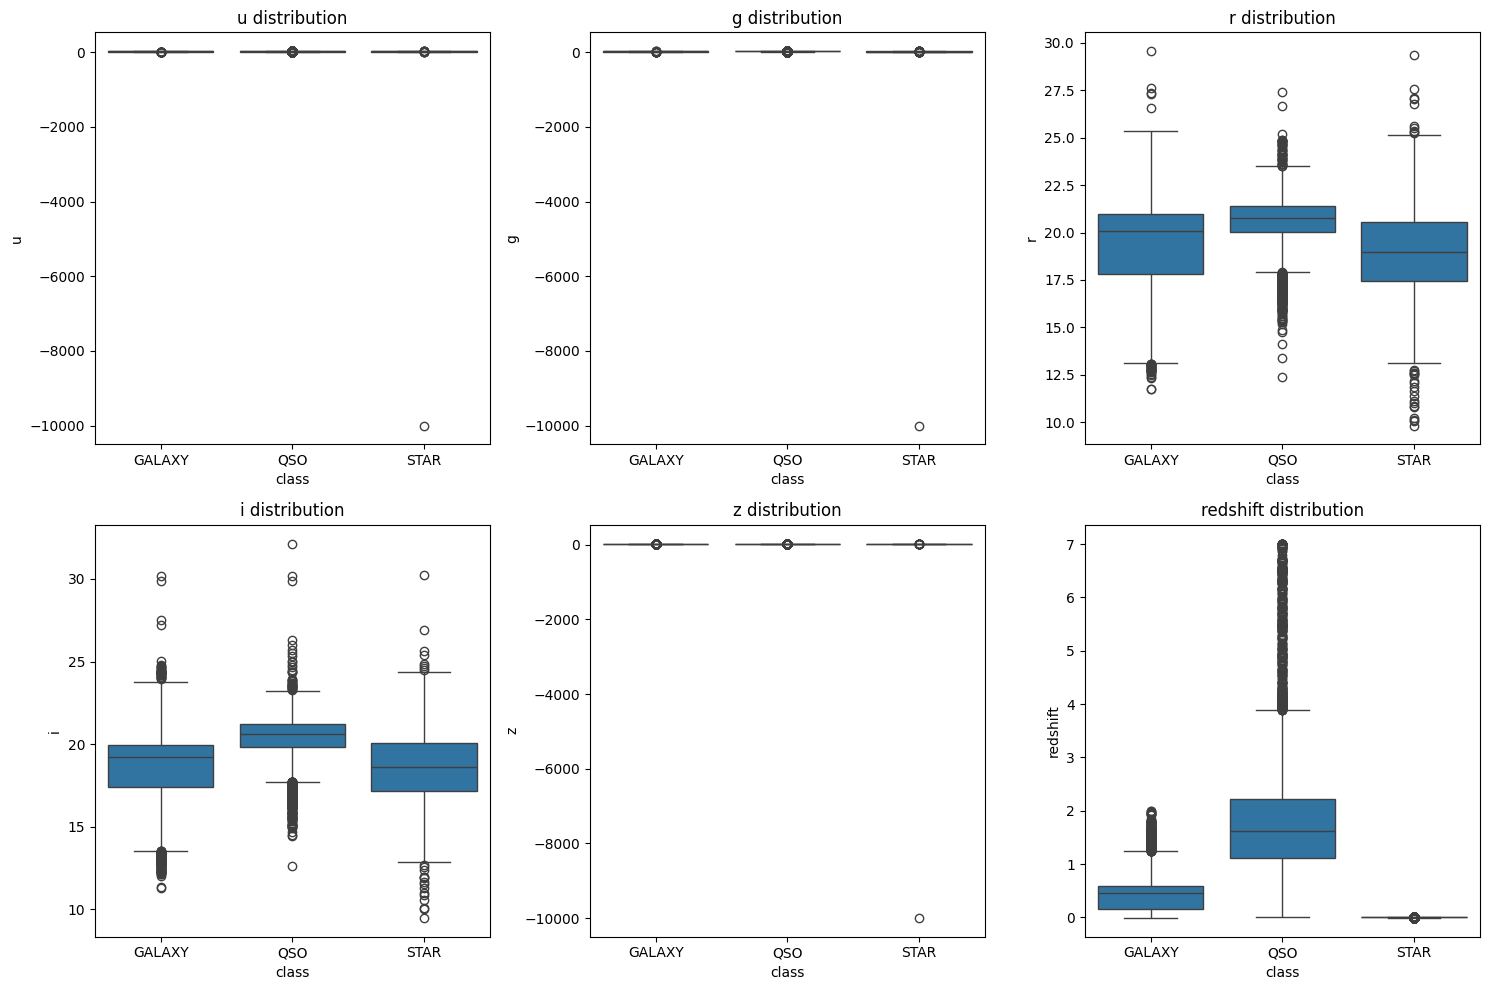

In [8]:
columns = ["u", "g", "r", "i", "z", "redshift"]

n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

idx = 0
for i in range(n_rows):
    for j in range(n_cols):
        col = columns[idx]
        sns.boxplot(data=df, x="class", y=col, ax=axes[i, j])
        axes[i, j].set_title(f"{col} distribution")
        idx += 1

plt.tight_layout()
plt.show()

### Correlation

<Axes: >

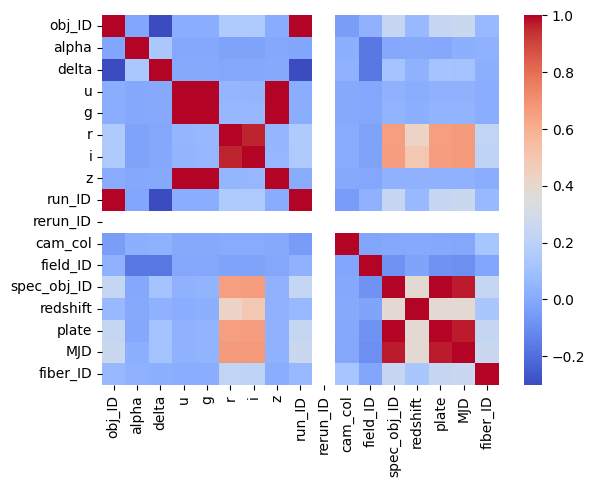

In [61]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

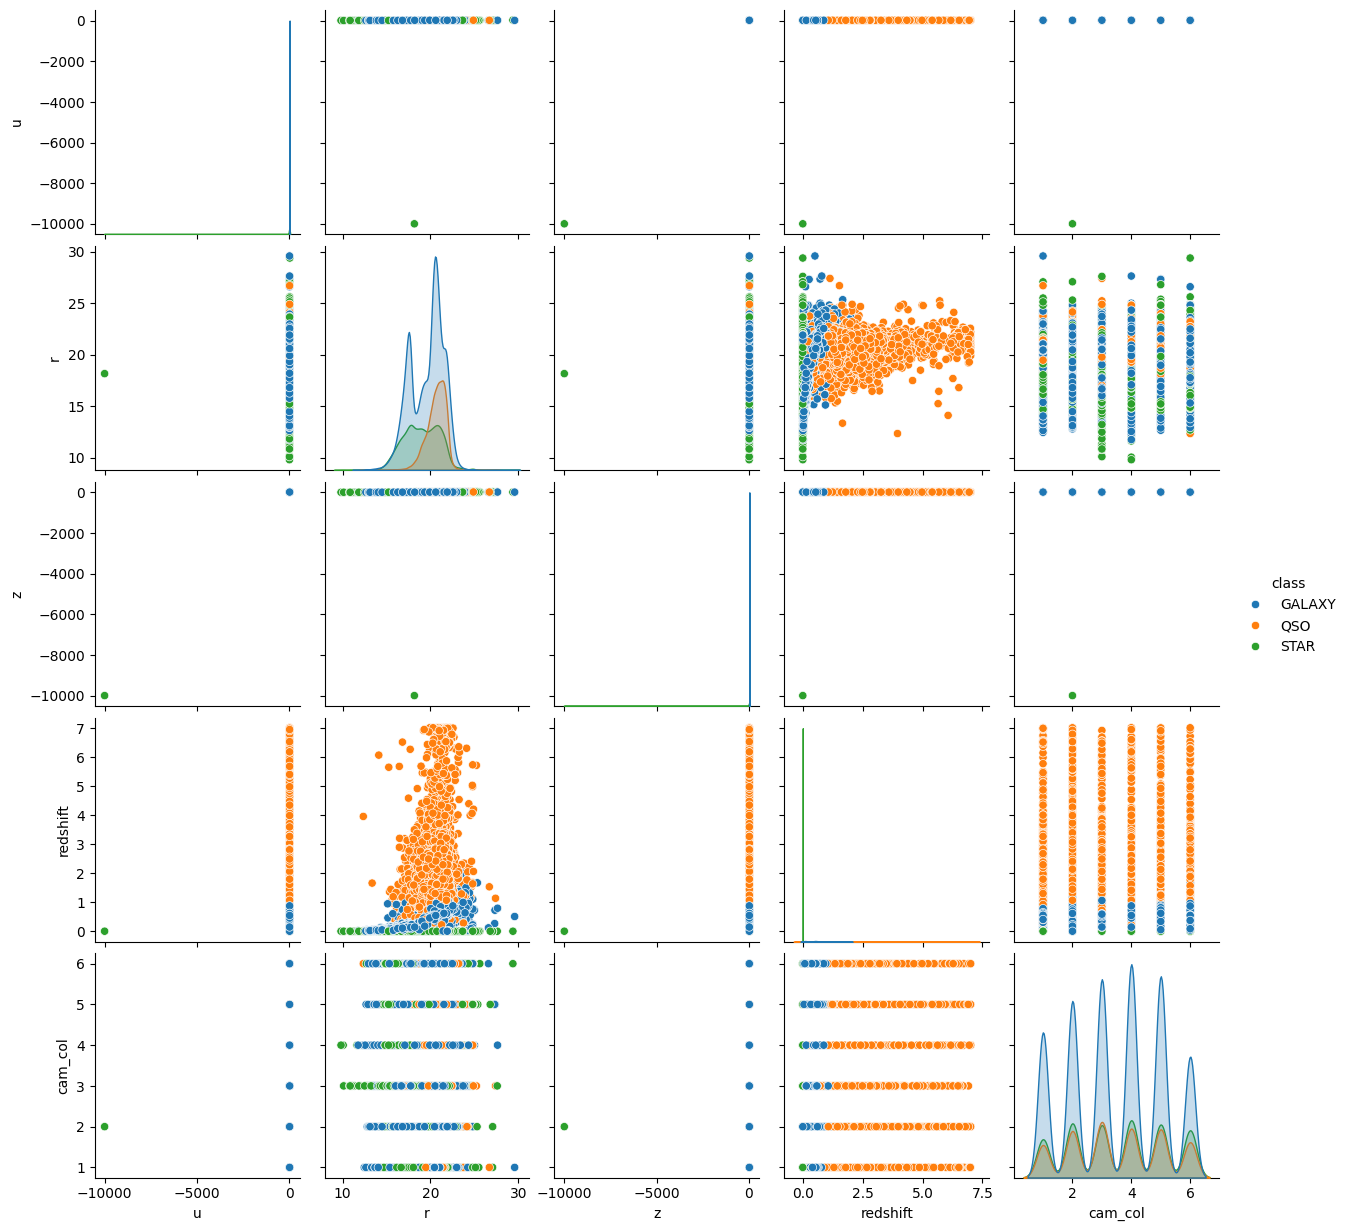

In [9]:
sns.pairplot(df[["u", "r", "z", "redshift", "cam_col", "class"]], hue="class")

## Data Engineering

### Feature creation: magnitude differences

In [4]:
df_augmented = df.copy()

df_augmented['u_g'] = df_augmented['u'] - df_augmented['g']
df_augmented['g_r'] = df_augmented['g'] - df_augmented['r']
df_augmented['r_i'] = df_augmented['r'] - df_augmented['i']
df_augmented['i_z'] = df_augmented['i'] - df_augmented['z']

### Feature cleaning

In [5]:
df_cleaned = df_augmented.copy()

columns_to_drop = ["obj_ID", "alpha", "delta","u", "g", "r", "i", "z", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "plate", "MJD", "fiber_ID"]
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

### Outlier treatment

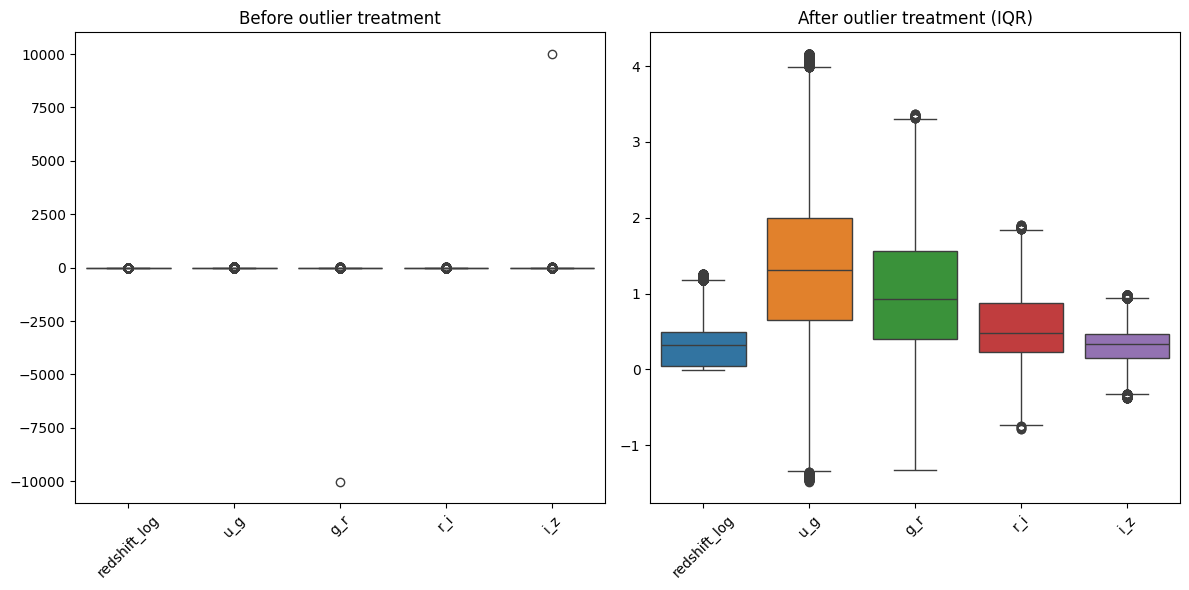

In [6]:
df_log = df_cleaned.copy()

df_log['redshift_log'] = np.log1p(df_log['redshift'])
df_log = df_log.drop(columns=["redshift"])

columns = ["redshift_log", "u_g", "g_r", "r_i", "i_z"]

Q1 = df_log[columns].quantile(0.25)
Q3 = df_log[columns].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df_log[columns] < (Q1 - 1.5 * IQR)) |
                (df_log[columns] > (Q3 + 1.5 * IQR))).any(axis=1)

df_iqr_filtered = df_log[~outlier_mask]
outlier_indices_iqr = df_log.index[outlier_mask].tolist()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_log[columns])
plt.title("Before outlier treatment")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df_iqr_filtered[columns])
plt.title('After outlier treatment (IQR)')
plt.xticks(rotation=45)
plt.tight_layout()


### New target distribution

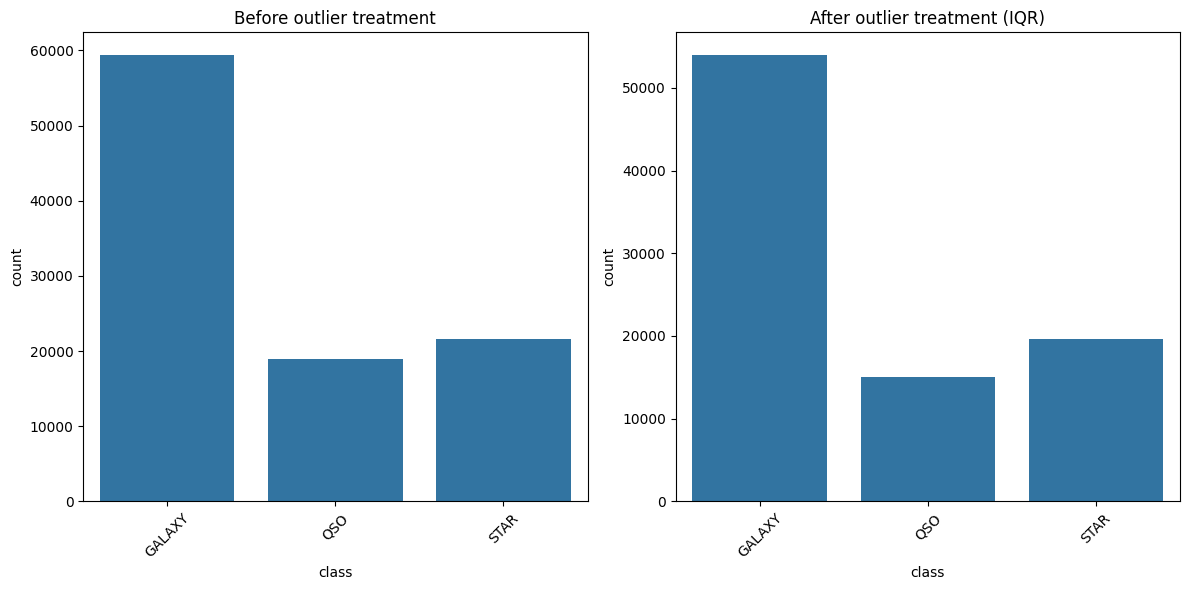

In [70]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="class")
plt.title("Before outlier treatment")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=df_iqr_filtered, x="class")
plt.title('After outlier treatment (IQR)')
plt.xticks(rotation=45)
plt.tight_layout()

## Train and test split

In [7]:
X = df_iqr_filtered.drop(columns=["class"])
y = df_iqr_filtered["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Preprocessing

In [8]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

num_cols = X_train.columns

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols)
])

## Models selection

Preferred models are tree-based or Support Vector Machine because the task is classification and the class distribution is imbalanced.

F1-macro scoring is the most suitable for imbalanced multiclass classification.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Random forest

In [10]:
pipe_rfc = Pipeline([
    ("preprocess", preprocess),
    # class_weight="balanced" for imbalanced distribution
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

param_distributions_rfc = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": randint(5, 20),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", None]
}

rs_rfc = RandomizedSearchCV(
    estimator=pipe_rfc,
    param_distributions=param_distributions_rfc,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

rs_rfc.fit(X_train, y_train_enc)

print("Random forest")
print(f"best_params: {rs_rfc.best_params_}")
print(f"cv_score: {rs_rfc.best_score_}")
print(f"test_score: {rs_rfc.score(X_test, y_test_enc)}")

Random forest
best_params: {'model__max_depth': 18, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 445}
cv_score: 0.9732883314408504
test_score: 0.9728788843909427


```
19m 49.9s
Random forest
best_params: {'model__max_depth': 18, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 445}
cv_score: 0.9732883314408504
test_score: 0.9728788843909427
```

### Ada boost

In [11]:
pipe_ada = Pipeline([
    ("preprocess", preprocess),
    ("model", AdaBoostClassifier(random_state=42))
])

param_distributions_ada = {
    "model__n_estimators": randint(50, 300),
    "model__learning_rate": uniform(0.01, 0.5)
}

rs_ada = RandomizedSearchCV(
    estimator=pipe_ada,
    param_distributions=param_distributions_ada,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

rs_ada.fit(X_train, y_train_enc)

print("Ada boost")
print(f"best_params: {rs_ada.best_params_}")
print(f"cv_score: {rs_ada.best_score_}")
print(f"test_score: {rs_ada.score(X_test, y_test_enc)}")

Ada boost
best_params: {'model__learning_rate': np.float64(0.19727005942368125), 'model__n_estimators': 142}
cv_score: 0.9350227120040353
test_score: 0.9357669036719894


```
3m 18.8s
Ada boost
best_params: {'model__learning_rate': np.float64(0.19727005942368125), 'model__n_estimators': 142}
cv_score: 0.9350227120040353
test_score: 0.9357669036719894
```

### Gradient boosting

In [12]:
pipe_gbc = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=42))
])

param_distributions_gbc = {
    "model__n_estimators": randint(100, 300),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__max_depth": randint(3, 8),
    "model__subsample": uniform(0.5, 0.5)
}

rs_gbc = RandomizedSearchCV(
    estimator=pipe_gbc,
    param_distributions=param_distributions_gbc,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

rs_gbc.fit(X_train, y_train_enc)

print("Gradient boosting")
print(f"best_params: {rs_gbc.best_params_}")
print(f"cv_score: {rs_gbc.best_score_}")
print(f"test_score: {rs_gbc.score(X_test, y_test_enc)}")

Gradient boosting
best_params: {'model__learning_rate': np.float64(0.052277267492428794), 'model__max_depth': 7, 'model__n_estimators': 164, 'model__subsample': np.float64(0.5078182033705969)}
cv_score: 0.9721087479273457
test_score: 0.9714710594886057


```
29m 27.5s
Gradient boosting
best_params: {'model__learning_rate': np.float64(0.052277267492428794), 'model__max_depth': 7, 'model__n_estimators': 164, 'model__subsample': np.float64(0.5078182033705969)}
cv_score: 0.9721087479273457
test_score: 0.9714710594886057
```

### XGBoost

In [10]:
pipe_xgb = Pipeline([
    ("preprocess", preprocess),
    # objective="multi:softmax" to return predicted class
    # tree_method="hist" to speed up training on large datasets
    ("model", XGBClassifier(random_state=42, objective="multi:softmax", tree_method="hist"))
])

param_distributions_xgb = {
    "model__n_estimators": randint(100, 300),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__max_depth": randint(3, 8),
    "model__subsample": uniform(0.5, 0.5),
    "model__colsample_bytree": uniform(0.5, 0.5)
}

rs_xgb = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_distributions_xgb,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

rs_xgb.fit(X_train, y_train_enc)

print("XGBoost")
print(f"best_params: {rs_xgb.best_params_}")
print(f"cv_score: {rs_xgb.best_score_}")
print(f"test_score: {rs_xgb.score(X_test, y_test_enc)}")

XGBoost
best_params: {'model__colsample_bytree': np.float64(0.811649063413779), 'model__learning_rate': np.float64(0.10926940745579475), 'model__max_depth': 7, 'model__n_estimators': 198, 'model__subsample': np.float64(0.7956488938538635)}
cv_score: 0.9715625564814024
test_score: 0.9689403863723675


```
1m 13.8s
XGBoost
best_params: {'model__colsample_bytree': np.float64(0.811649063413779), 'model__learning_rate': np.float64(0.10926940745579475), 'model__max_depth': 7, 'model__n_estimators': 198, 'model__subsample': np.float64(0.7956488938538635)}
cv_score: 0.9715625564814024
test_score: 0.9689403863723675
```

### SVM

In [11]:
pipe_svm = Pipeline([
    ("preprocess", preprocess),
    # class_weight="balanced" for imbalanced distribution
    ("model", SVC(random_state=42, class_weight='balanced'))
])

param_distributions_svm = {
    "model__C": loguniform(0.1, 100),
    "model__gamma": loguniform(1e-4, 1),
    "model__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "model__degree": randint(2, 5), # poly
    "model__coef0": uniform(0, 1)
}

rs_svm = RandomizedSearchCV(
    estimator=pipe_svm,
    param_distributions=param_distributions_svm,
    n_iter=20,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

rs_svm.fit(X_train, y_train_enc)

print("SVM")
print(f"best_params: {rs_svm.best_params_}")
print(f"cv_score: {rs_svm.best_score_}")
print(f"test_score: {rs_svm.score(X_test, y_test_enc)}")

SVM
best_params: {'model__C': np.float64(65.84106160121607), 'model__coef0': np.float64(0.8948273504276488), 'model__degree': 3, 'model__gamma': np.float64(0.08111253665497056), 'model__kernel': 'rbf'}
cv_score: 0.9618231173570087
test_score: 0.9614571704932283


```
21m 26.8s
SVM
best_params: {'model__C': np.float64(65.84106160121607), 'model__coef0': np.float64(0.8948273504276488), 'model__degree': 3, 'model__gamma': np.float64(0.08111253665497056), 'model__kernel': 'rbf'}
cv_score: 0.9618231173570087
test_score: 0.9614571704932283
```

### Results

| Model                 | CV F1_macro | Test F1_macro | Best hyperparameters                                                             |
|-----------------------|-------------|--------------------------------------------------------------------------------------------------|
| **Random Forest**     | 0.9733      | 0.9729        | `n_estimators=445`, `max_depth=18`, `max_features='log2'`, `min_samples_split=2`, `min_samples_leaf=2` |
| **Gradient Boosting** | 0.9721      | 0.9715        | `learning_rate≈0.0523`, `max_depth=7`, `n_estimators=164`, `subsample≈0.508`     |
| **XGBoost**           | 0.9716      | 0.9689        | `learning_rate≈0.1093`, `max_depth=7`, `n_estimators=198`, `subsample≈0.796`, `colsample_bytree≈0.812` |
| **SVM (RBF)**         | 0.9618      | 0.9615        | `C≈65.84`, `gamma≈0.0811`, `kernel='rbf'`, `degree=3`, `coef0≈0.895`             |
| **AdaBoost**          | 0.9350      | 0.9358        | `learning_rate≈0.197`, `n_estimators=142`                                        |


## Model evaluation